<a href="https://colab.research.google.com/github/olchan/DEEPLEARNINGstudy/blob/main/%5B%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%9D%98_%EC%A0%95%EC%84%9D_2%ED%8C%90%5D_Pytorch_%EA%B8%B0%EB%B0%98_%EC%8B%A0%EA%B2%BD%EB%A7%9D_%EA%B5%AC%ED%98%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/darksigma/Fundamentals-of-Deep-Learning-Book

> Pytorch Tutorial : https://docs.pytorch.org/tutorials/beginner/basics/intro.html

## **Pytorch**
- conda : 하나의 PC 안에서 여러 개의 독립적인 '가상 환경(Virtual Environment)' 을 만들고 관리할 수 있게 해주는 도구

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


pytorch에서는 주로 tensor라는 데이터 구조를 활용하여 모델에 적용될 입력값의 형태, layer 간 연결에 필요한 가중치 등을 나타낸다.

In [2]:
zeros_tensor = torch.zeros((2,3))
ones_tensor = torch.ones((2,3))
rand_tensor = torch.rand((2,3))
print(zeros_tensor)
print(ones_tensor)
print(rand_tensor)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.5036, 0.8726, 0.8789],
        [0.7697, 0.7121, 0.4302]])


In [3]:
arr = [1,2]
tensor = torch.tensor(arr) # 1과 2가 각각 개별적인 원소로 들어간다.
val = 2.0
tensor_2 = torch.tensor(val)
print(tensor)
print(tensor_2)

tensor([1, 2])
tensor(2.)


리스트 [1, 2] 의 원소들이 텐서의 데이터로 들어갔다. 정수 리스트를 넣었기 때문에 기본적으로 정수형 텐서(int64) 가 된다. 그러나, 딥러닝 연산은 주로 실수형 연산을 수행한다. 그래서 나중에 연산 오류를 방지하기 위해 주로 다음과 같이 타입을 명시해준다.

In [4]:
tensor = torch.tensor([1, 2], dtype=torch.float32)
print(tensor)

tensor([1., 2.])


In [5]:
# tensor의 크기
print(zeros_tensor.shape)

torch.Size([2, 3])


In [6]:
# 하나의 tensor에는 동일한 data type만 저장 가능
print(zeros_tensor.dtype)

torch.float32


In [7]:
# 텐서(Tensor)는 기본적으로 CPU 메모리에 생성되어 저장됨

# GPU를 활용해 연산을 가속화하고 싶다면,
# 명시적으로 해당 텐서를 GPU 메모리로 옮겨주는 과정이 필요

# .cuda() 와 같은 명령어를 사용하여 데이터를 전송하며,
# 연산을 수행하는 모든 텐서가 같은 장치에 있어야 함
zeros_tensor.device

device(type='cpu')

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

arr = [1,2]
x_t = torch.tensor(arr, dtype = torch.float32, device = device)
print(x_t)

x_t = x_t.to(device, dtype = int)
print(x_t)

cpu
tensor([1., 2.])
tensor([1, 2])


> requires_grad : PyTorch의 핵심 기능 중 하나인 Autograd(자동 미분) 엔진을 제어하는 설정
-  파라미터(가중치)를 업데이트하기 위한 Gradient를 계산할지 말지 결정하는 스위치
- requires_grad=True : 텐서를 생성할 때 이 옵션을 True 로 설정하면, PyTorch는 해당 텐서에서 일어나는 모든 연산 과정을 추적

In [9]:
import torch

# 1. 미분 가능한 텐서 생성 (x = 2.0)
x = torch.tensor([2.0], requires_grad=True)

# 2. 연산 수행 (y = x^2)
y = x ** 2

# 3. 역전파 수행 (기울기 계산 시작)
""" y가 scalar일 때만 동작
-> 어떤 결과값 y에 대해 입력값 x가 얼마나 영향을 주었는가를 계산!"""
y.backward()

# 4. 결과 확인 (dy/dx = 2 * x = 4.0)
print(x.grad)  # 출력: tensor(4.)

tensor([4.])


grad()

In [10]:
""""보통 손실함수에 대한 gradient로 많이 사용"""
import torch

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2

# y의 모든 요소를 더해서 스칼라로 변환 (y = 1 + 4 + 9 = 14)
loss = y.sum()
loss.backward()

print(x.grad)  # [2*1, 2*2, 2*3] -> tensor([2., 4., 6.])

tensor([2., 4., 6.])


> grad.zero_()
- PyTorch의 독특한 점 중 하나는 backward() 를 여러 번 호출하면 기울기가 기존 값에 누적(add) 된다는 것. 그래서 매 학습 단계마다 새로운 기울기를 구하려면 optimizer.zero_grad() 나 x.grad.zero_() 를 통해 이전 값을 지워주는 과정이 필수

In [11]:
# "기울기 폭주 (Gradient Exploding) 와 학습 실패" 사례
# 똑같은 가중치를 가진 모델을 (A) 매번 초기화할 때 와 (B) 초기화를 깜빡했을 때 를 비교
import torch

# 가중치 역할을 하는 텐서 x (초깃값 1.0)
x = torch.tensor([1.0], requires_grad=True)

# 시나리오: 3번의 학습 단계를 거친다고 가정
for i in range(1, 6):
    # 단순한 예측값 연산 (y = x * 2)
    y = x * 2

    # 역전파 수행 (dy/dx = 2)
    y.backward()

    print(f"Step {i} - 현재 기울기(x.grad): {x.grad}")

    # 원래는 여기서 x.grad.zero_()를 해줘야 함!
    """그렇지 않으면 계속 2가 더해주게 된다.
    backward() 가 호출되면 PyTorch 내부에서는
    실제로 기존의 .grad 값에 새로 계산한 값을
    더하는 연산($+= \text{operation}$)  이 일어남"""

Step 1 - 현재 기울기(x.grad): tensor([2.])
Step 2 - 현재 기울기(x.grad): tensor([4.])
Step 3 - 현재 기울기(x.grad): tensor([6.])
Step 4 - 현재 기울기(x.grad): tensor([8.])
Step 5 - 현재 기울기(x.grad): tensor([10.])


In [12]:
x1_t = torch.tensor([[1,2],[3,4]])

x2_t = torch.tensor([[1,2,3],[4,5,6]])

torch.matmul(x1_t, x2_t) # Returns tensor([[9,12,15],[19,26,33]])

# 2x2 <-> 2x3 matmul -> 2x3

tensor([[ 9, 12, 15],
        [19, 26, 33]])

In [13]:
i,j,k = 0,1,1
x3_t = torch.tensor([[[3,7,9],[2,4,5]],[[8,6,2],[3,9,1]]])
print(x3_t, end = "\n\n")
print(x3_t.size())
# out:
# tensor([[[3, 7, 9],
#          [2, 4, 5]],
#         [[8, 6, 2],
#          [3, 9, 1]]])

x3_t[i,j,k]
# out:
# tensor(4)

tensor([[[3, 7, 9],
         [2, 4, 5]],

        [[8, 6, 2],
         [3, 9, 1]]])

torch.Size([2, 2, 3])


tensor(4)

## **Pytorch 기반 신경망 구현**

In [14]:
import torch.nn as nn

In [15]:
in_dim, out_dim = 256, 10
vec = torch.randn(256)

In [16]:
"""
# 입력 데이터를 선형 레이어(Linear Layer)에 통과시켜 결과를 연산하는 가장 기본적인 인공신경망
# 무작위(Random) 가중치로 구성된 Fully Connected Layer
"""
layer = nn.Linear(in_dim, out_dim, bias=True) # input 차원 : 256  출력 차원 : 10
out = layer(vec)

In [17]:
out # 입력값 vec이 layer를 통과한 결과

tensor([-0.1394,  0.6277, -0.4736, -0.6010, -0.0909, -0.2420, -0.9387, -0.6098,
        -0.4072,  0.0304], grad_fn=<ViewBackward0>)

In [18]:
### 순방향 신경망 ###
in_dim, feature_dim, out_dim = 784, 256, 10
vec = torch.randn(784)
layer1 = nn.Linear(in_dim, feature_dim, bias=True)
layer2 = nn.Linear(feature_dim, out_dim, bias=True)
out = layer2(layer1(vec))
out

tensor([-0.6063,  0.0830, -0.3528, -0.0925,  0.7538,  0.2420, -0.1237, -0.5009,
        -0.6518,  0.2543], grad_fn=<ViewBackward0>)

In [19]:
### 활성화 함수 ###

relu = nn.ReLU()
out = layer2(relu(layer1(vec)))
print(out)

tensor([-0.2631,  0.1527, -0.2944,  0.1939,  0.2378,  0.2911,  0.1543, -0.3094,
        -0.5789,  0.0961], grad_fn=<ViewBackward0>)


> ## **모든 신경망을 subclassing 하는 기본 클래스 : nn.Module**

- 왜 함수형태로 하지 않고, nn.Module을 상속 받아서 사용하는 것일까?
- 모델 내부에 nn.Linear 등을 선언하면, nn.Module 은 그 안에 숨겨진 무수히 많은 가중치($W$)와 편향($b$)들을 알아서 추적하고, model(x) 만 해도 forward 가 실행되며, 미분 추적 장치(grad_fn)를 붙이고 훅(Hook)을 실행하는 등 학습에 필요한 밑작업을 자동으로 수행해주기 떄문.
- nn.Module 을 상속받은 클래스의 생성자(__init__) 내부에서 **self.linear = nn.Linear(10, 5) 와 같이 파이토치의 내장 레이어를 정의하면, 부모 클래스인 nn.Module 이 백그라운드에서 이를 감지하고 자동으로 관리 대상에 등록**

In [20]:
# nn.Module 클래스 안의 핵심 : __init__과 forward 메서드

class BaseClassifier(nn.Module):
  def __init__(self, in_dim, feature_dim, out_dim):
    super(BaseClassifier, self).__init__()
    self.layer1 = nn.Linear(in_dim, feature_dim, bias = True)
    self.layer2 = nn.Linear(feature_dim, out_dim, bias = True)
    self.relu = nn.ReLU()
  # __init__(self): Constructor
  # 역할: 모델에 필요한 모든 가중치, 레이어(예: nn.Linear, nn.ReLU 등)를
  # 미리 선언하고 초기화

  def forward(self, x):
    x = self.layer1(x)
    x = self.relu(x)
    out = self.layer2(x)
    return out
# forward(self, x)
# __init__에서 준비한 부품들을 가지고, 입력 데이터 x 가
### 어떻게 흘러가서 최종 출력(Output)을 만들어낼지 연산 순서를 정의 ###

In [21]:
no_examples = 10
in_dim, feature_dim, out_dim = 784, 256, 10
x = torch.randn((no_examples, in_dim))
model = BaseClassifier(in_dim, feature_dim, out_dim)
out = model(x) # 이 과정에서 암시적으로 forward 함수를 호출함.
# 클래스 인스턴스를 함수처럼 호출하면 내부적으로 forward 메서드를 실행하는 규칙이 있음
print(out)

tensor([[-2.8041e-01, -1.7118e-02, -2.4087e-01,  2.3317e-01,  1.6726e-01,
         -7.5529e-02, -1.1657e-01,  1.0728e-01, -6.4057e-02, -1.1071e-01],
        [-7.2019e-02,  7.1127e-02, -2.0220e-02, -4.3076e-01,  1.3367e-01,
          3.6342e-02, -4.1260e-04,  3.0474e-01, -2.1332e-01, -1.6464e-01],
        [-7.9150e-02,  1.7606e-01, -1.7055e-01, -1.0649e-01,  2.0375e-01,
          2.5328e-01,  2.5482e-01,  5.1182e-01, -2.4349e-01, -1.6553e-01],
        [-5.2112e-01,  3.2549e-01, -2.6568e-01, -1.0295e-01, -6.8672e-02,
         -1.1340e-01,  3.2350e-02,  5.3457e-01, -2.4213e-01,  1.5951e-01],
        [-4.6883e-01,  2.0627e-01, -4.1149e-01, -2.0886e-02,  7.2691e-02,
         -3.3527e-01, -1.6703e-01,  3.9426e-01,  6.6188e-02, -1.6471e-01],
        [-2.8782e-01,  2.5461e-01, -1.9561e-01,  9.8186e-02, -9.6691e-02,
          6.4314e-02, -1.9280e-01,  3.1669e-01, -2.4063e-01,  1.1849e-01],
        [ 5.8436e-02, -8.8714e-02, -4.7689e-01, -1.8812e-01,  4.2693e-02,
          2.4521e-01, -1.3837e-0

In [22]:
loss = nn.CrossEntropyLoss()
# 모델의 출력(out)은 [-0.21, 3.74, 0.15, ...] 처럼 가공되지 않은 점수(Logits)
# Cross Entropy는 이 점수들을 0 ~ 1 사이의 확률 값(총합이 1이 되도록)으로 변환
# 이후 모델이 예측한 확률 중에서 진짜 정답(target)에 해당하는 확률에 대해 loss를 계산.

target = torch.tensor([0,3,2,8,2,9,3,7,1,6])
computed_loss = loss(out, target)
computed_loss.backward()
# 최종 오차(computed_loss)에서 출발하여, 거꾸로(Backward) 모델의 입력 방향으로 가며
# "Loss를 줄이려면 모델 내부의 가중치(Weights)들을 어떻게 바꿔야 하는가?" 를 계산
# 🛠️ 실행 후 일어나는 변화
# 이 한 줄이 실행되면, model 내부의 각 레이어가 가진 파라미터(weight, bias)에
# .grad 라는 속성이 새로 생기거나 업데이트됨

> .backward()
out(모델의 예측값)과 target(실제 정답)의 차이를 수치화한 것이 최종 Loss(오차)이고, 그 Loss에 영향을 준 모델 내부의 모든 파라미터(가중치와 편향)에 대해 "네가 최종 오차에 이만큼 기여했으니, 미분값(Gradient)은 이만큼이야"라고 계산하는 것이 backward() 의 핵심 기능

In [23]:
computed_loss

tensor(2.3839, grad_fn=<NllLossBackward0>)

- 첫 번째 레이어(layer1)는 784차원의 입력을 받아서 256차원으로 내보내는 역할을 하기에 레이어 안에는 256개의 뉴런(노드) 이 존재하며  뉴런 하나가 784개의 가중치(Weight) 를 가지고 있음.
- 그 후, nn.CrossEntropyLoss 는 기본 설정(reduction='mean')상 10개 샘플 각각에서 나온 오차들의 '평균' 을 최종 Loss(하나의 스칼라 값)로 반환하기에, 내부적으로 샘플 개수(10개)로 나누어 평균 Gradient를 계산

In [24]:
# 첫 번째 레이어의 가중치(Weight)에 대한 기울기(Gradient) 출력
print("fc1 weights gradient:")
print(model.layer1.weight.grad)
print(model.layer1.weight.grad.size())

fc1 weights gradient:
tensor([[ 3.7106e-03,  8.1428e-03,  1.4518e-02,  ...,  2.3740e-03,
         -5.8658e-04,  1.3310e-02],
        [ 9.1909e-03,  3.7183e-03,  3.3688e-03,  ..., -5.1119e-03,
         -6.3283e-03,  7.1352e-03],
        [ 1.0574e-02,  1.0065e-02,  3.2827e-03,  ...,  1.0089e-02,
          1.7884e-02, -5.3564e-03],
        ...,
        [-8.8952e-03, -8.8531e-03, -4.4926e-03,  ...,  6.0532e-06,
         -1.4477e-02,  2.1755e-03],
        [-1.1387e-03, -3.2830e-03, -1.5431e-04,  ..., -3.8023e-03,
         -1.0319e-02,  1.7020e-03],
        [-6.2640e-04, -6.9006e-04, -8.8396e-03,  ...,  6.0232e-03,
         -1.8175e-03, -5.7679e-03]])
torch.Size([256, 784])


>> 원래 Gradient는 편미분 벡터가 맞습니다.
그런데 왜 출력된 결과에서는 가중치 하나당 그냥 숫자 하나 로만 보였을까?
- model.layer1.weight.grad 안에 들어있는 수많은 숫자들은 독립된 별개의 값이 아니라, '전체 가중치 공간'이라는 거대한 다차원 공간에서 Loss가 가장 가파르게 증가하는 방향을 가리키는 거대한 Gradient 벡터의 성분(원소)들
- **각 w들을 변수로 보고 편미분!!**

In [25]:
### 신경망의 각 Parameter에 접근하기 ###
for p in model.parameters():
  print(p.shape)

torch.Size([256, 784])
torch.Size([256])
torch.Size([10, 256])
torch.Size([10])


 > Layer 가 많은 모델들은 어떻게 처리를 하는가?
 - 아무리 복잡하고 거대한 GPT 같은 모델이라도 실제 코드를 뜯어보면 "기본 블록 하나 잘 정의해 두고, for 루프나 nn.Sequential 로 수십 번 반복해서 쌓은 구조" 로 되어 있음

In [26]:
### nn.Sequential ###
# 레이어들이 한 줄로 이어지는 단순한 구조일 떄 사용

import torch.nn as nn

class DeepNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # 일일이 layer1, layer2 정의할 필요 없이 한 번에 묶기
        # 여러 개의 레이어(Layer)를 순차적으로 연결하여 하나의 묶음(블록)으로 한 번에 정의할 때 사용
        self.feature_extractor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        # 여러 레이어를 단 한 줄로 통과!
        return self.feature_extractor(x)

In [27]:
### 반복문(for 루프)과 nn.ModuleList ###

class BlockNetwork(nn.Module):
    def __init__(self, num_layers=50): # 레이어 50개 쌓기
        super().__init__()

        self.layers = nn.ModuleList()

        # 반복문으로 50개의 레이어를 뚝딱 생성
        for _ in range(num_layers):
            self.layers.append(nn.Linear(256, 256))
            self.layers.append(nn.ReLU())

        self.final_layer = nn.Linear(256, 10)

    def forward(self, x):
        # 실행할 때도 반복문으로 순서대로 통과!
        for layer in self.layers:
            x = layer(x)
        return self.final_layer(x)

In [28]:
### 블록(Block) 단위 설계 ###
# '반복되는 거대한 하나의 묶음(Block)' 을 먼저 작은 nn.Module 클래스로 정의해둔 후,
# 메인 모델에서는 이 블록을 반복문으로 조립하는 방식으로 주로 사용

# 1. 반복될 하나의 상자(블록)를 먼저 정의
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 딥러닝에서 자주 쓰이는 잔차 연결(Skip Connection) 구조
        return x + self.relu(self.linear(x))

# 2. 메인 모델에서는 이 블록을 원하는 만큼 쌓기
class GiantModel(nn.Module):
    def __init__(self, num_blocks=100): # 블록 100개 = 레이어 수백 개
        super().__init__()

        # 리스트 컴프리헨션과 nn.Sequential의 조합
        self.blocks = nn.Sequential(*[ResBlock(256) for _ in range(num_blocks)])
        self.outputs = nn.Linear(256, 10)

    def forward(self, x):
        x = self.blocks(x)
        return self.outputs(x)

> ResNet, Transformer, GPT 등에서는 레이어를 수십, 수백 개씩 쌓습니다. 이때 GiantModel 하나에다가 Linear 100개, ReLU 100개를 일일이 다 적거나 반복문으로 꼬아서 넣으면 가독성이 떨어지고, 재사용성(residual 부분만 수정하고 싶은 경우)이 떨어지기에, 다음과 같이 블록 단위로 설계함

> torch.optim : gradient descent를 위한 optimizer

- 이전에 계산한 computed_loss.backward() 를 통해 모델의 각 가중치에 .grad가 저장되어 있음.

-  PyTorch는 backward() 를 호출할 때, 기존에 계산되어 있던 .grad 값을 지우고 새로 쓰는 게 아니라, 기존 값에 새로운 미분값을 더해버리는 성질(Accumulate) 이 있어서, 한 번 업데이트(step())를 끝냈다면, 다음 학습을 위해 반드시 optimizer.zero_grad() 로 모든 .grad 값을  $0$  으로 초기화해주어야 함.

In [29]:
from torch import optim

lr = 1e-3
optimizer = optim.SGD(model.parameters(), lr = lr)

optimizer.step()
optimizer.zero_grad()

# **Dataset**

❓ 왜 PyTorch에서는 데이터셋을 클래스로 만들까?

만약  컴퓨터에 있는 모든 이미지 파일을 한 번에 RAM 메모리에 다 올리면 컴퓨터는 멈춰버린다. PyTorch의 Dataset 클래스는 "데이터 전체를 메모리에 올리지 말고, 모델이 '나 n번 데이터 줘!'라고 요청할 때마다 그때그때 하드디스크에서 n번 이미지를 읽어서 가공해 주는 역할을 한다.

In [30]:
from torch.utils.data import Dataset, DataLoader

In [31]:
import numpy as np
labels = np.array([2, 0, 4, 1])
np.save('labels',labels)

In [32]:
labels_1 = np.load('labels.npy')
labels_1

array([2, 0, 4, 1])

In [33]:
!mkdir -p data
!mkdir -p data/train
!wget -O data/train/img_0.jpg -nc -q https://github.com/darksigma/Fundamentals-of-Deep-Learning-Book/raw/master/ch05_implementing_nn_pytorch/data/train/img_0.jpg
!wget -O data/train/img_1.jpg -nc -q https://github.com/darksigma/Fundamentals-of-Deep-Learning-Book/raw/master/ch05_implementing_nn_pytorch/data/train/img_1.jpg
!wget -O data/train/img_2.jpg -nc -q https://github.com/darksigma/Fundamentals-of-Deep-Learning-Book/raw/master/ch05_implementing_nn_pytorch/data/train/img_2.jpg
!wget -O data/train/img_3.jpg -nc -q https://github.com/darksigma/Fundamentals-of-Deep-Learning-Book/raw/master/ch05_implementing_nn_pytorch/data/train/img_3.jpg
!wget -O data/train/labels.npy -nc -q https://github.com/darksigma/Fundamentals-of-Deep-Learning-Book/raw/master/ch05_implementing_nn_pytorch/data/train/labels.npy

- Dataset : 파이토치가 미리 만들어 둔 Dataset 이라는 표준 설계도를 상속받아 나만의 데이터셋 공장 만들기

- DataLoader : ImageDataset 은 데이터 한 건(__getitem__)을 가져올 줄만 아는 단순한 공장이기에, 미니배치, 셔플, CPU 멀티 코어를 활용한 멀티프로세싱을 위해 data loader를 사용

> 파이토치 공식 문서나 전 세계의 수많은 AI 엔지니어들이 만드는 커스텀 데이터셋도 결국 이 큰 틀(__init__, __getitem__, __len__) 안에서만 움직인다. getitem에서 대부분의 전처리를 진행한다. 이는 init에서 하면 메모리 부담이 많아지기 때문이다.

In [34]:
import os
from PIL import Image
from torchvision import transforms

class ImageDataset(Dataset):
  def __init__(self, img_dir, label_file):
    super(ImageDataset, self).__init__()
    self.img_dir = img_dir
    self.labels = torch.tensor(np.load(label_file, allow_pickle=True))
    # 미리 저장해 둔 정답 파일(예: labels.npy)을 불러온 뒤,
    # 파이토치 연산이 가능하도록 torch.tensor (파이토치의 숫자 형태) 로 변환하여 self.labels 에 저장
    self.transforms = transforms.ToTensor()
    # 일반 이미지(PIL Image)를 파이토치 전용 숫자인 Tensor로 바꾸고,
    # 픽셀 값을 0~1 사이로 정규화(Normalize) 해 주는 변환 도구

  def __getitem__(self, idx):
    img_pth = os.path.join(self.img_dir, "img_{}.jpg".format(idx))
    img = Image.open(img_pth)
    img = self.transforms(img).flatten()
    label = self.labels[idx]
    return {"data":img, "label":label}

  def __len__(self):
    return len(self.labels)

In [35]:
import torch
train_dataset = ImageDataset(img_dir='./data/train/', label_file='./data/train/labels.npy')

train_loader = DataLoader(train_dataset,
                          batch_size=2,
                          shuffle=True)

In [36]:
for minibatch in train_loader:
  data, labels = minibatch['data'], minibatch['label']
  print(data, labels)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([4, 0])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([1, 2])


> ### Pytorch를 활용하여 MNIST 분류기 구축

In [37]:
import matplotlib.pyplot as plt
import torch
from torch import optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# Seed 고정
torch.manual_seed(0) # 파이토치의 CPU 연산 무작위성만 고정

In [38]:
class BaseClassifier(nn.Module):
  def __init__(self, in_dim, feature_dim, out_dim):
    super().__init__()
    self.classifier = nn.Sequential(
        nn.Linear(in_dim, feature_dim, bias = True),
        nn.ReLU(),
        nn.Linear(feature_dim, out_dim, bias = True)
    )

  def forward(self, x):
    return self.classifier(x)

train_dataset = MNIST(".", train=True,
                      download=True, transform=ToTensor())
test_dataset = MNIST(".", train=False,
                     download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset,
                          batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset,
                         batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.91MB/s]


In [53]:
# Instantiate model, optimizer, and hyperparameter(s)
in_dim, feature_dim, out_dim = 784, 256, 10
lr=1e-3
loss_fn = nn.CrossEntropyLoss()
epochs=10
classifier = BaseClassifier(in_dim, feature_dim, out_dim)
optimizer = optim.SGD(classifier.parameters(), lr=lr)

def train(classifier=classifier,
          optimizer=optimizer,
          epochs=epochs,
          loss_fn=loss_fn):

  classifier.train()
  loss_lt = []
  for epoch in range(epochs):
    running_loss = 0.0
    for minibatch in train_loader:
      data, target = minibatch
      data = data.flatten(start_dim=1)
      out = classifier(data)
      computed_loss = loss_fn(out, target)
      computed_loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      # Keep track of sum of loss of each minibatch
      running_loss += computed_loss.item()
    loss_lt.append(running_loss/len(train_loader))
    print("Epoch: {} train loss: {}".format(epoch+1, running_loss/len(train_loader)))

  plt.plot([i for i in range(1,epochs+1)], loss_lt)
  plt.xlabel("Epoch")
  plt.ylabel("Training Loss")
  plt.title(
      "MNIST Training Loss: optimizer {}, lr {}".format("SGD", lr))
  plt.show()

  # Save state to file as checkpoint
  torch.save(classifier.state_dict(), 'mnist.pt')

Epoch: 1 train loss: 2.2115534269479293
Epoch: 2 train loss: 1.9913828760576147
Epoch: 3 train loss: 1.6980490458291222
Epoch: 4 train loss: 1.383903627202455
Epoch: 5 train loss: 1.12443641844843
Epoch: 6 train loss: 0.9407582041551309
Epoch: 7 train loss: 0.8150914604984113
Epoch: 8 train loss: 0.7265404652176636
Epoch: 9 train loss: 0.6621586050687314
Epoch: 10 train loss: 0.6131400085016608


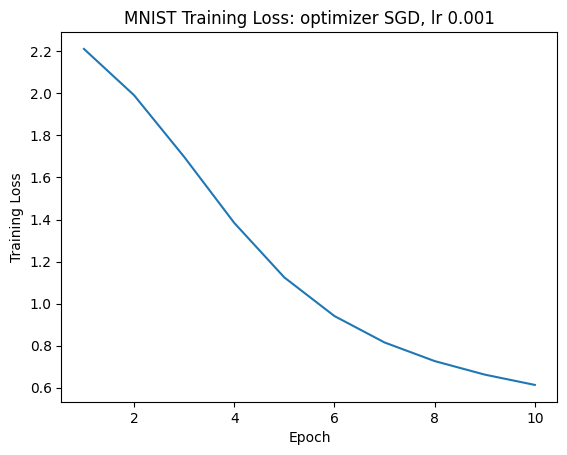

In [54]:
train()

> -  with torch.no_grad(): 블록으로 코드를 감싸주면?
- 미분 기록 장치 Off : "어차피 가중치 안 고칠 거니까 메모장(연산 그래프) 접어두자."
- 효과 : 컴퓨터 메모리(VRAM) 사용량이 드라마틱하게 줄어들고, 쓸데없는 기록 연산을 안 하니 예측 속도가 훨씬 빨라집니다.

In [57]:
def test(classifier=classifier,
          loss_fn = loss_fn):
  classifier.eval()
  accuracy = 0.0
  computed_loss = 0.0

  with torch.no_grad():
      for data, target in test_loader:
          data = data.flatten(start_dim=1)
          out = classifier(data)
          _, preds = out.max(dim=1)
          # 모델의 최종 출력인 out : 이미지 하나당 10개의 숫자(0부터 9까지 각각의 확률 점수)
          # out.max(dim=1) 을 실행하면 파이토치는 두 가지 값을 반환
          # 가장 큰 값 자체, 그 값이 있는 인덱스
          # accuracy 측정에는 맞다 / 틀리다 만 보면 되기에 preds만 반환하고 _는 버림.

          # Get loss and accuracy
          computed_loss += loss_fn(out, target)
          accuracy += torch.sum(preds == target)

      print("Test loss: {}, test accuracy: {}".format(
          computed_loss.item()/(len(test_loader)*64), accuracy*100.0/(len(test_loader)*64)))

In [58]:
import torch

# 1. 껍데기 준비: 원래 모델과 똑같은 구조의 클래스가 정의되어 있어야 합니다.
# (위에서 정의한 BaseClassifier 클래스가 이 파일에도 적혀있어야 합니다)
in_dim, feature_dim, out_dim = 784, 256, 10
new_classifier = BaseClassifier(in_dim, feature_dim, out_dim) # 👈 지금은 껍데기만 있는 초기 상태

# 2. 가중치 불러오기: 저장했던 'mnist.pt' 파일을 파이토치로 읽어옵니다.
saved_weights = torch.load('mnist.pt')

# 3. 덮어씌우기: 읽어온 가중치를 내 껍데기 모델에 주입합니다.
new_classifier.load_state_dict(saved_weights)

print("학습된 가중치 로드 완료! 이제 테스트를 진행할 수 있습니다.")

# 4. 테스트 함수 호출 (새로 로드한 모델을 인자로 넘겨줌)
test(classifier=new_classifier)

학습된 가중치 로드 완료! 이제 테스트를 진행할 수 있습니다.
Test loss: 0.008923927689813505, test accuracy: 86.65406036376953
